<a href="https://colab.research.google.com/github/Ashcodes69/Models/blob/main/skinsight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ["KAGGLE_API_TOKEN"] = " "
!kaggle datasets download -d "andrewmvd/isic-2019" --unzip

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/isic-2019
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 9.10G/9.10G [01:19<00:00, 123MB/s]



In [ ]:
for root, dirs, files in os.walk("/content"):
    level = root.replace("/content", "").count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level > 2:
        for file in files:
            print(f"{indent} {file}")

content/
  .config/
    configurations/
    logs/
      2026.05.21/
       13.32.19.276288.log
       13.31.37.559893.log
       13.32.06.268636.log
       13.32.07.912587.log
       13.31.55.610753.log
       13.32.18.574065.log
  ISIC_2019_Training_Input/
    ISIC_2019_Training_Input/
  sample_data/


In [ ]:
import pandas as pd
metadata_df = pd.read_csv('/content/ISIC_2019_Training_Metadata.csv')
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25331 entries, 0 to 25330
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   image                25331 non-null  object 
 1   age_approx           24894 non-null  float64
 2   anatom_site_general  22700 non-null  object 
 3   lesion_id            23247 non-null  object 
 4   sex                  24947 non-null  object 
dtypes: float64(1), object(4)
memory usage: 989.6+ KB


In [ ]:
groundTruth_df = pd.read_csv('/content/ISIC_2019_Training_GroundTruth.csv')
print(groundTruth_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25331 entries, 0 to 25330
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   25331 non-null  object 
 1   MEL     25331 non-null  float64
 2   NV      25331 non-null  float64
 3   BCC     25331 non-null  float64
 4   AK      25331 non-null  float64
 5   BKL     25331 non-null  float64
 6   DF      25331 non-null  float64
 7   VASC    25331 non-null  float64
 8   SCC     25331 non-null  float64
 9   UNK     25331 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.9+ MB
None


In [ ]:
temp_var = groundTruth_df.drop(columns=["image"]).sum()
print(temp_var)

MEL      4522.0
NV      12875.0
BCC      3323.0
AK        867.0
BKL      2624.0
DF        239.0
VASC      253.0
SCC       628.0
UNK         0.0
dtype: float64


In [ ]:
gTruth_df = groundTruth_df.drop(columns=["UNK"])

class_cols = ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"]

gTruth_df["label"] = gTruth_df[class_cols].idxmax(axis=1)

gTruth_df = gTruth_df.drop(columns=class_cols)
print(gTruth_df.head())

          image label
0  ISIC_0000000    NV
1  ISIC_0000001    NV
2  ISIC_0000002   MEL
3  ISIC_0000003    NV
4  ISIC_0000004   MEL


In [ ]:
class_mapping = {
    "MEL": 0,
    "NV": 1,
    "BCC": 2,
    "AK": 3,
    "BKL": 4,
    "DF": 5,
    "VASC": 6,
    "SCC": 7,
}
gTruth_df["label"] = gTruth_df['label'].map(class_mapping)
print(gTruth_df.head())

          image  label
0  ISIC_0000000      1
1  ISIC_0000001      1
2  ISIC_0000002      0
3  ISIC_0000003      1
4  ISIC_0000004      0


In [ ]:
from sklearn.model_selection import train_test_split

X = gTruth_df['image']
y = gTruth_df["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"len of \nX_train: {len(X_train)}, y_train: {len(y_train)}")
print(f"\nX_val: {len(X_val)}, y_val: {len(y_val)}")

len of 
X_train: 20264, y_train: 20264

X_val: 5067, y_val: 5067


In [ ]:
import albumentations as A

Mean= [0.485, 0.456, 0.406]
Std= [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(),
    A.Rotate(),
    A.ColorJitter(),
    A.RandomBrightnessContrast(),
    A.Normalize(mean=Mean, std=Std),
    A.ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=Mean, std=Std),
    A.ToTensorV2()
])

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import torch

class SkinDiseaseDataset(Dataset):
    def __init__(self, image_names, labels, image_dir, transform=None):
        self.image_names = image_names.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_names[idx] + ".jpg")

        image = Image.open(image_path).convert("RGB")
        image = np.array(image)

        if self.transform:
            agumented = self.transform(image=image)
            image = agumented["image"]

        label = self.labels[idx]
        label = torch.tensor(label, dtype=torch.long)

        return image, label


In [ ]:
train_dataset = SkinDiseaseDataset(
    image_names=X_train,
    labels=y_train,
    image_dir="/content/ISIC_2019_Training_Input/ISIC_2019_Training_Input",
    transform=train_transform
)

val_dataset = SkinDiseaseDataset(
    image_names=X_val,
    labels=y_val,
    image_dir="/content/ISIC_2019_Training_Input/ISIC_2019_Training_Input",
    transform=val_transform
)
print(f"len of \ntrain dataset: {len(train_dataset)} \n test dataset: {len(val_dataset)}")

len of 
train dataset: 20264 
 test dataset: 5067


In [ ]:
image, label = train_dataset[0]
print(image.shape, label)

torch.Size([3, 224, 224]) tensor(1)


In [ ]:
print("Train samples:", len(train_dataset))
print("Val samples: ", len(val_dataset))

Train samples: 20264
Val samples:  5067


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset= train_dataset,
    batch_size= 32,
    shuffle= True
)

val_loader = DataLoader(
    dataset= val_dataset,
    batch_size= 32,
    shuffle= False
)

In [ ]:
train_counts = y_train.value_counts().sort_index().values
counts_tensor = torch.tensor(train_counts, dtype=torch.float32)

weights = 1.0 / counts_tensor
weights = (weights / weights.sum()) * len(train_counts)
print(weights)
print(y_train.value_counts().sort_index())

tensor([0.1489, 0.0523, 0.2027, 0.7765, 0.2567, 2.8214, 2.6678, 1.0735])
label
0     3618
1    10300
2     2658
3      694
4     2099
5      191
6      202
7      502
Name: count, dtype: int64


In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 129MB/s]


In [ ]:
for param in model.parameters():
    param.requires_grad = True

print(model.classifier)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1536, out_features=8, bias=True)
)


In [ ]:
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features=1536, out_features=8)
)
print(model.classifier)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1536, out_features=8, bias=True)
)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

criterion = nn.CrossEntropyLoss(weight= weights.to(device))
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4)

In [ ]:
import time
def train(model, train_loader, val_loader, epochs, checkpoint_dir="/content/drive/MyDrive/checkpoints"):

    os.makedirs(checkpoint_dir, exist_ok=True)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    print("=" * 60)
    print("TRAINING STARTED!")
    print("=" * 60)
    total_start = time.time()

    for epoch in range(epochs):

        model.train()

        train_loss, train_correct = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += (outputs.argmax(1)==labels).sum().item()

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.inference_mode():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_correct += (outputs.argmax(1)==labels).sum().item()

        train_acc = 100 * train_correct / len(train_loader.dataset)
        val_acc = 100 * val_correct / len(val_loader.dataset)

        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss/ len(val_loader)

        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train loss: {train_loss_avg:.4f} | Train acc: {train_acc:.2f}% | "
            f"Val loss: {val_loss_avg:.4f} | Val acc: {val_acc:.2f}%"
            )
        # save checkpoint at each epoch
        checkpoint_path= os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch+1}.pth")
        torch.save({
            "epoch": epoch+1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_sict": optimizer.state_dict(),
            "history": history
        }, checkpoint_path)

        # remove precious checkpoint to save space
        prev_checkpoint = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch}.pth")
        if os.path.exists(prev_checkpoint):
            os.remove(prev_checkpoint)

        print(f"Checkpoint saved: epoch {epoch+1}")

    total_time = time.time() - total_start
    print("=" * 60)
    print(f"Training Complete! Total time: {total_time/60:.2f} mins")
    print("=" * 60)

    return history


In [ ]:
history = train(model, train_loader, val_loader, epochs=10)

TRAINING STARTED!
Epoch [1/10] | Train loss: 1.3966 | Train acc: 55.70% | Val loss: 1.0187 | Val acc: 66.13%
Checkpoint saved: epoch 1
Epoch [2/10] | Train loss: 1.1059 | Train acc: 62.03% | Val loss: 0.9047 | Val acc: 69.41%
Checkpoint saved: epoch 2
Epoch [3/10] | Train loss: 0.9620 | Train acc: 64.64% | Val loss: 0.7994 | Val acc: 69.03%
Checkpoint saved: epoch 3
Epoch [4/10] | Train loss: 0.8428 | Train acc: 68.38% | Val loss: 0.7393 | Val acc: 70.52%
Checkpoint saved: epoch 4
Epoch [5/10] | Train loss: 0.7704 | Train acc: 69.63% | Val loss: 0.7080 | Val acc: 73.34%
Checkpoint saved: epoch 5
Epoch [6/10] | Train loss: 0.7138 | Train acc: 71.50% | Val loss: 0.6605 | Val acc: 75.76%
Checkpoint saved: epoch 6
Epoch [7/10] | Train loss: 0.6273 | Train acc: 73.33% | Val loss: 0.6491 | Val acc: 77.01%
Checkpoint saved: epoch 7
Epoch [8/10] | Train loss: 0.5646 | Train acc: 75.70% | Val loss: 0.6609 | Val acc: 76.89%
Checkpoint saved: epoch 8
Epoch [9/10] | Train loss: 0.5392 | Train acc:

In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/skin_disease_model.pth')
print("Model saved")

Model saved


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate(model, val_loader):
    model.eval()
    all_probs = []
    all_preds = []
    all_labels = []
    with torch.inference_mode():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_probs = np.vstack(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    class_names = ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"]
    print("=" * 60)
    print("CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # AUC-ROC per class
    print("=" * 60)
    print("AUC-ROC PER CLASS")
    print("=" * 60)
    for i, class_name in enumerate(class_names):
        auc = roc_auc_score((all_labels == i).astype(int), all_probs[:, i])
        print(f"{class_name}: {auc:.4f}")

    # Confusion matrix
    print("=" * 60)
    print("CONFUSION MATRIX")
    print("=" * 60)
    cm = confusion_matrix(all_labels, all_preds)
    print(cm)

        # Build Confusion Matrix Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title("Confusion Matrix Heatmap")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()
    plt.show()

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         MEL       0.65      0.72      0.68       904
          NV       0.93      0.80      0.86      2575
         BCC       0.81      0.81      0.81       665
          AK       0.56      0.73      0.63       173
         BKL       0.64      0.72      0.68       525
          DF       0.42      0.81      0.55        48
        VASC       0.69      0.98      0.81        51
         SCC       0.51      0.75      0.61       126

    accuracy                           0.78      5067
   macro avg       0.65      0.79      0.70      5067
weighted avg       0.80      0.78      0.78      5067

AUC-ROC PER CLASS
MEL: 0.9149
NV: 0.9536
BCC: 0.9819
AK: 0.9744
BKL: 0.9426
DF: 0.9823
VASC: 0.9988
SCC: 0.9809
CONFUSION MATRIX
[[ 652  122   22   18   64   11    1   14]
 [ 282 2056   61   13  110   29   14   10]
 [  20   15  540   26   16    8    7   33]
 [   3    0   14  126   17    2    0   11]
 [  47   28   15   32  380

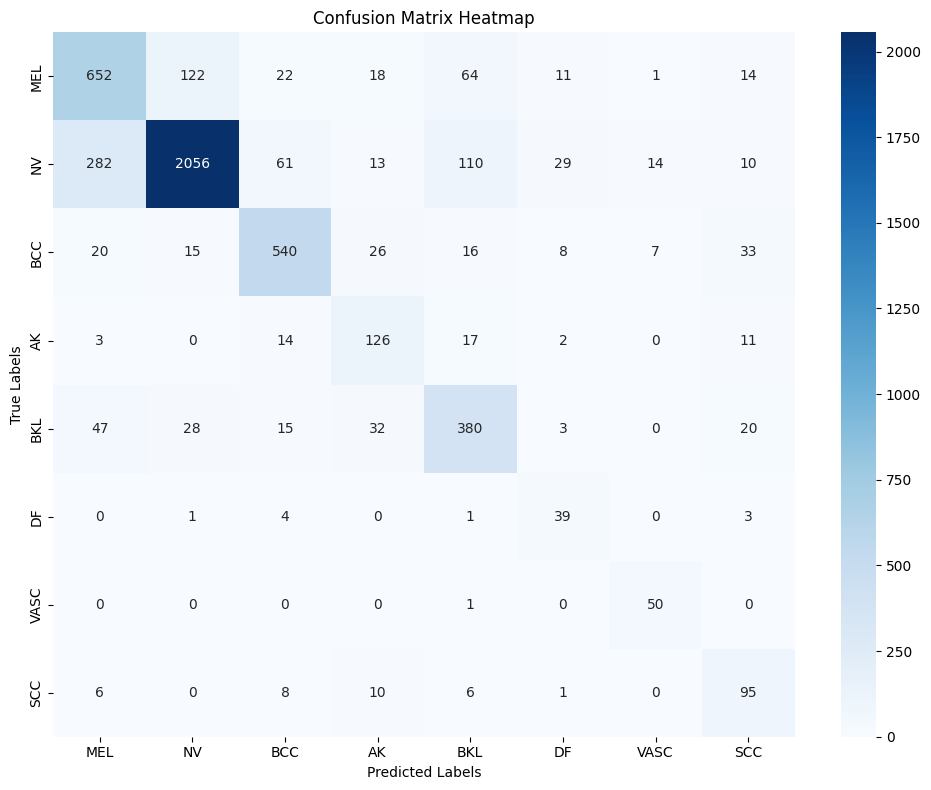

In [ ]:
evaluate(model, val_loader)

In [ ]:
# Rebuild the architecture first
import torchvision.models as models
import torch.nn as nn

model = models.efficientnet_b3(weights=None)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features=1536, out_features=8)
)

# Then load your saved weights
model.load_state_dict(torch.load('/content/drive/MyDrive/skin_disease_model.pth', map_location="cpu"))
model.eval()

# Then export
dummy_input = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model,
    dummy_input,
    '/content/drive/MyDrive/skin_disease_model.onnx',
    export_params=True,
    opset_version=17,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    },
    dynamo=False  # Force legacy exporter
)

size = os.path.getsize('/content/drive/MyDrive/skin_disease_model.onnx')
print(f"Model size: {size / (1024*1024):.2f} MB")
print("ONNX model exported!")

/tmp/ipykernel_1235/1583201371.py:18: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Model size: 40.80 MB
ONNX model exported!


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['skin_disease_model.pth', 'skin_disease_model.onnx.data', 'skin_disease_model.onnx', 'checkpoints']


In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/skin_disease_model.onnx')
files.download('/content/drive/MyDrive/skin_disease_model.onnx.data')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

idx_to_class = {v: k for k, v in class_mapping.items()}
classes_ordered = [idx_to_class[i] for i in range(len(idx_to_class))]
print(json.dumps(classes_ordered, indent=2))

[
  "MEL",
  "NV",
  "BCC",
  "AK",
  "BKL",
  "DF",
  "VASC",
  "SCC"
]
